# Inflation & Equity Sectors: Does CPI Drive Performance?
#### by Akaravit Raiklongkru
---
## Introduction

Inflation is one of the most closely watched macroeconomic indicators by investors.
When the Consumer Price Index (CPI) rises, different sectors of the economy respond in
very different ways; some benefit from pricing power, others suffer from rising input costs
or compressed consumer spending.

**Goal:** Investigate whether U.S. CPI (Year-over-Year % change) shows a statistically
meaningful correlation with the Year-over-Year returns of the 11 SPDR S&P 500 Sector ETFs
over the period 2021–2025.

**Research Question:**
> *Which equity sectors perform best and worst during periods of high inflation,
> and how strong is that relationship?*

**Data Sources:**
- **CPI (CPIAUCSL):** U.S. Bureau of Labor Statistics via the Federal Reserve FRED API
- **Sector ETFs:** 11 SPDR Select Sector ETFs via `yfinance` (XLK, XLF, XLE, XLV, XLI, XLP, XLY, XLU, XLB, XLRE, XLC)

**Time Period:** January 2020 – December 2025 (YoY returns available from January 2021)

---
## How to Use This Notebook

Follow these steps to reproduce all results from scratch:

### 1. Prerequisites
Make sure you have Python 3.9+ installed. Install required packages:
```bash
pip install yfinance pandas matplotlib seaborn scipy requests python-dotenv
```

### 2. API Key Setup
This notebook uses the [FRED API](https://fred.stlouisfed.org/docs/api/api_key.html) to fetch CPI data.
1. Register for a free API key at https://fred.stlouisfed.org/
2. Create a `.env` file in the **same directory** as this notebook
3. Add the following line to your `.env` file:
```
API_KEY=your_fred_api_key_here
```
> ⚠️ Never commit your `.env` file to version control. Add it to `.gitignore`.

### 3. Run All Cells
Run cells **top to bottom** in order. Each cell depends on the output of previous cells.
In Jupyter: `Kernel → Restart & Run All`

### 4. Outputs
The notebook will generate two CSV files in the working directory:
- `master_data.csv` — merged monthly CPI + sector ETF YoY returns
- `correlations.csv` — Pearson correlation coefficients and p-values vs. CPI

---
## Data Pipeline Overview

The diagram below shows the end-to-end data pipeline used in this notebook.

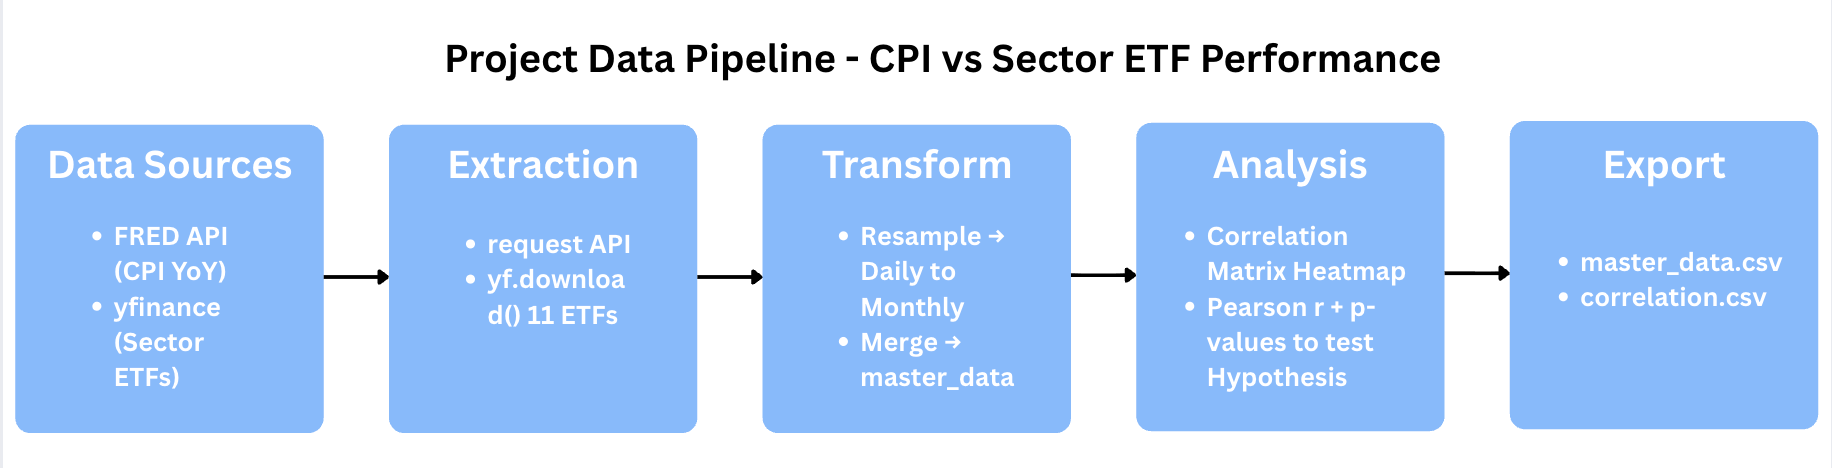

*From raw API calls through transformation, analysis, and export.*

### Welcome to my project!! 🤩
---

In [87]:
## Import necessary modules
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1) API checking
---

In [88]:
## Check that key can be used
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.environ.get("API_KEY")

if api_key:
    print(f"Key loaded: {api_key[:3]}...")
else:
    print("ERROR: API_KEY not found. Check your .env file.")

Key loaded: 1ea...


### 2) Request CPI YoY form FRED API
---

In [89]:
# Import modules
import requests
import pandas as pd


# Define the FRED API endpoint
base_url = 'https://api.stlouisfed.org/fred/'

'''
Get observation data from the FRED API
'''

# Assign endpoint
obs_endpoint = 'series/observations'

# Assign parameters
series_id = 'CPIAUCSL'
start_date = '2000-01-01'
end_date = '2025-12-31'
ts_frequency = 'q'
ts_units = 'pc1'

obs_params = {
    'series_id': series_id,
    'api_key': api_key,
    'file_type': 'json',
    'observation_start': start_date,
    'observation_end': end_date,
    # 'frequency': ts_frequency
    'units': ts_units
}

# Make request to FRED API
response = requests.get(base_url + obs_endpoint, params=obs_params)

if response.status_code == 200:
    res_data = response.json()
    obs_data = pd.DataFrame(res_data['observations'])
    
    # Cleaning the DataFrame
    obs_data['date'] = pd.to_datetime(obs_data['date'])
    obs_data.set_index('date', inplace=True)
    
    # Convert 'value' to float (FRED returns strings by default)
    obs_data['value'] = pd.to_numeric(obs_data['value'], errors='coerce')
    
    # Drop unnecessary columns to keep it clean
    obs_data = obs_data[['value']]
    
    # VIEW THE OUTPUT
    print("--- CPI Data (First 5 rows) ---")
    print(obs_data.head())
    
else:
    print(f"Error {response.status_code}: {response.text}")

--- CPI Data (First 5 rows) ---
              value
date               
2000-01-01  2.79296
2000-02-01  3.21797
2000-03-01  3.76214
2000-04-01  3.01386
2000-05-01  3.13253


### 3) Get Sector ETFs from yahoofinance
---

In [90]:
import yfinance as yf
import pandas as pd

# List of the 11 major SPDR Select Sector ETFs
sector_tickers = [
    'XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLP', 
    'XLY', 'XLU', 'XLB', 'XLRE', 'XLC'
]

start_date = "2020-01-01"
end_date = "2025-12-31"

print(f"Downloading historical data for {len(sector_tickers)} sector ETFs...")

# Download the data
raw_data = yf.download(sector_tickers, start=start_date, end=end_date)

# Bulletproof extraction: checks if 'Adj Close' exists (older yfinance versions)
# If not, it uses 'Close' (newer yfinance versions where 'Close' is already adjusted)
if 'Adj Close' in raw_data.columns:
    sector_prices = raw_data['Adj Close']
else:
    sector_prices = raw_data['Close']

# Drop the timezone information from the index for cleaner data manipulation
sector_prices.index = sector_prices.index.tz_localize(None)

# Display the first 5 rows and data info
print("\nFirst 5 rows of Prices:")
print(sector_prices.head())

print("\nData Summary:")
print(sector_prices.info())

[*********************100%***********************]  11 of 11 completed


First 5 rows of Prices:
Ticker            XLB        XLC        XLE        XLF        XLI        XLK  \
Date                                                                           
2020-01-02  26.765249  51.052105  23.356091  27.642971  75.150558  44.294174   
2020-01-03  26.333130  50.722797  23.286692  27.349459  75.005692  43.796173   
2020-01-06  26.218479  51.400242  23.467894  27.331676  75.032852  43.900505   
2020-01-07  26.187618  51.466106  23.406204  27.153790  74.878944  43.881538   
2020-01-08  26.280216  51.833038  23.020668  27.331676  75.132439  44.351105   

Ticker            XLP       XLRE        XLU        XLV        XLY  
Date                                                               
2020-01-02  52.989937  31.014639  26.264923  92.306107  60.155186  
2020-01-03  52.905121  31.241852  26.318426  91.501694  59.643265  
2020-01-06  53.015366  31.249964  26.343124  92.071106  59.809166  
2020-01-07  52.608276  30.909153  26.306080  91.890335  59.714375  
2020-0

### 4) Manipulate and Merge the data into one table
---

In [91]:
# 1. Resample daily sector prices to monthly (taking the last price of each month)
# Note: 'ME' stands for Month-End frequency
monthly_prices = sector_prices.resample('ME').last()

# 2. Calculate Year-over-Year (12-month) percentage returns for the ETFs
yoy_sector_returns = monthly_prices.pct_change(12) * 100

# 3. Align the indexes to merge cleanly
# FRED dates usually default to the 1st of the month, ETF dates will be the end of the month.
# The easiest fix is to convert both indexes to a Year-Month period format.
obs_data.index = obs_data.index.to_period('M')
yoy_sector_returns.index = yoy_sector_returns.index.to_period('M')

# Merge them into a single master dataframe
master_data = pd.merge(obs_data, yoy_sector_returns, left_index=True, right_index=True, how='inner')

# Rename the 'value' column to 'CPI_YoY' for clarity
master_data.rename(columns={'value': 'CPI_YoY'}, inplace=True)

# Drop any NaN values caused by the 12-month rolling return calculation
master_data.dropna(inplace=True)

display(master_data.head())

,CPI_YoY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
2021-01,1.37384,25.279086,25.122705,-21.521858,-0.861831,6.641971,36.947017,4.294442,-3.055097,-6.668368,18.035127,30.726232
2021-02,1.66982,42.588295,42.206240,13.445482,24.667332,26.513783,49.749652,12.227979,5.005600,-2.775538,23.699563,40.685875
2021-03,2.66782,78.378367,66.978860,77.994341,67.118319,69.444006,66.808813,28.895910,32.119263,19.420452,33.885964,72.718249
2021-04,4.13308,63.193148,56.398216,37.034397,62.581447,61.226126,54.271209,22.751366,30.774772,20.398270,23.592851,54.663847
2021-05,4.91826,60.445756,46.950338,42.018210,65.827109,57.770263,42.601845,22.875462,29.486298,12.796349,21.896202,40.276939


In [92]:
master_data.info()
print()
master_data.describe()

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 59 entries, 2021-01 to 2025-12
Freq: M
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CPI_YoY  59 non-null     float64
 1   XLB      59 non-null     float64
 2   XLC      59 non-null     float64
 3   XLE      59 non-null     float64
 4   XLF      59 non-null     float64
 5   XLI      59 non-null     float64
 6   XLK      59 non-null     float64
 7   XLP      59 non-null     float64
 8   XLRE     59 non-null     float64
 9   XLU      59 non-null     float64
 10  XLV      59 non-null     float64
 11  XLY      59 non-null     float64
dtypes: float64(12)
memory usage: 6.0 KB



,CPI_YoY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,4.523990,12.399669,18.607210,27.605843,20.354890,17.611154,21.904924,8.707393,8.510902,10.643834,9.375460,13.929975
std,2.173780,19.601744,28.084058,29.852165,23.631494,17.931782,21.688185,8.330465,18.207827,12.957158,11.471100,21.667700
min,1.373840,-12.296923,-39.671829,-21.521858,-17.532601,-13.944662,-27.726285,-6.070533,-26.249275,-12.706597,-11.349179,-36.272192
25%,2.836135,-1.866531,3.422937,5.348968,-1.314928,6.023953,8.724835,2.110752,-4.253784,-0.081422,1.192342,6.949654
50%,3.360800,9.673050,26.586688,16.832763,20.612690,17.353463,25.852262,6.809768,5.584186,11.993612,8.504840,16.578688
75%,6.281110,21.555741,36.645968,51.475387,34.837609,24.764237,37.598817,14.049761,24.773815,19.439934,18.539476,27.157975
max,8.979360,78.378367,66.978860,109.541853,71.806799,69.444006,66.808813,28.895910,46.100987,41.590278,33.885964,72.718249


#### 5.1) Visualization of CPI vs Sector Performace to see the overall trend
---

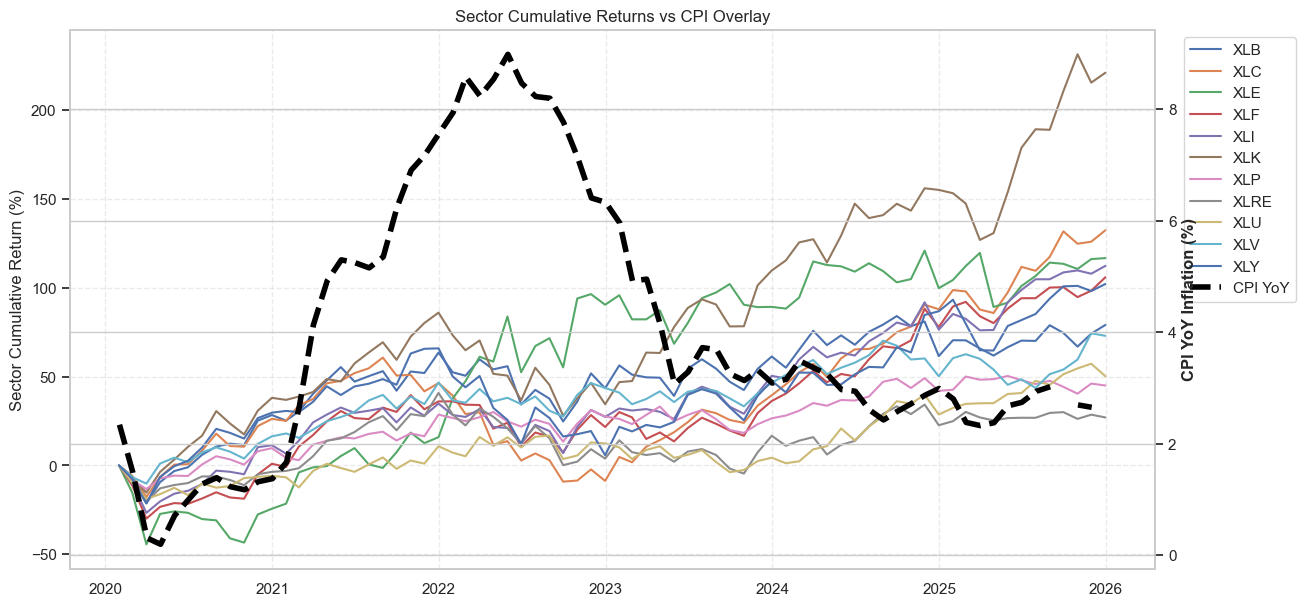

In [93]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate cumulative returns (starts at 0%)
cum_returns = (monthly_prices / monthly_prices.iloc[0]) - 1
cum_returns = cum_returns * 100 

# 2. Force both indices to Datetimes
cum_returns.index = pd.to_datetime(cum_returns.index.astype(str))
cpi_data = obs_data.copy()
cpi_data.index = pd.to_datetime(cpi_data.index.astype(str))

# Filter CPI data to only show dates from your ETF start date onward
cpi_data = cpi_data[cpi_data.index >= cum_returns.index.min()]

# 3. Create the base plot
fig, ax1 = plt.subplots(figsize=(14, 7))

for sector in cum_returns.columns:
    ax1.plot(cum_returns.index, cum_returns[sector], label=sector)

ax1.set_ylabel("Sector Cumulative Return (%)")
ax1.set_title("Sector Cumulative Returns vs CPI Overlay")
ax1.grid(True, linestyle='--', alpha=0.4)

# 4. Create the secondary axis and plot CPI
ax2 = ax1.twinx()
ax2.plot(cpi_data.index, cpi_data['value'], color='black', linewidth=4, linestyle='--', label="CPI YoY")
ax2.set_ylabel("CPI YoY Inflation (%)", fontweight='bold')

# 5. Clean legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.show()

#### 5.2) Which sector perform the best?
---

In [94]:
# Grab the most recent date and sort the values from highest to lowest
final_returns = cum_returns.iloc[-1].sort_values(ascending=False)

# Print the results clearly
print("🏆 Sector Cumulative Returns (Best to Worst):")
print("-" * 45)
for sector, return_val in final_returns.items():
    print(f"{sector: <10} {return_val:>8.2f} %")

🏆 Sector Cumulative Returns (Best to Worst):
---------------------------------------------
XLK          221.20 %
XLC          132.47 %
XLE          116.80 %
XLI          112.42 %
XLF          106.02 %
XLY          102.21 %
XLB           79.16 %
XLV           73.03 %
XLU           50.25 %
XLP           45.03 %
XLRE          27.06 %


- you can see that tech sector performed the best despite facing inflation

#### 5.3) Look deeper into during rising inflation and after inflation
---

In [95]:
# Returns during Rising Inflation (Jan 2021 to June 2022)
rising_returns = (monthly_prices.loc['2022-06-30'] / monthly_prices.iloc[0]) - 1

# Returns during Cooling Inflation (July 2022 to the end of your data)
cooling_returns = (monthly_prices.iloc[-1] / monthly_prices.loc['2022-06-30']) - 1

print("Winners during RISING inflation:\n", rising_returns.sort_values(ascending=False).head(3))
print("\nWinners during COOLING inflation:\n", cooling_returns.sort_values(ascending=False).head(3))

Winners during RISING inflation:
 Ticker
XLE    0.525144
XLK    0.366585
XLV    0.345227
dtype: float64

Winners during COOLING inflation:
 Ticker
XLK    1.350401
XLC    1.261660
XLI    0.893267
dtype: float64


- During rising inflation -> XLE perform the best
- During cooling inflation -> XLK perform the best

---
### 6) Analysis: CPI vs. Sector ETF Correlation

In [96]:
from scipy import stats
import pandas as pd

sector_cols = [c for c in master_data.columns if c != 'CPI_YoY']

# Compute Pearson r and two-tailed p-value for each sector vs CPI
results = []
for sector in sector_cols:
    r, p = stats.pearsonr(master_data['CPI_YoY'], master_data[sector])
    results.append({
        'Sector': sector,
        'Pearson_r': round(r, 4),
        'p_value': round(p, 4),
        'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'
    })

corr_df = pd.DataFrame(results).sort_values('Pearson_r', ascending=False).reset_index(drop=True)

print("=" * 55)
print(" Pearson Correlation: CPI YoY vs. Sector ETF YoY Returns")
print("=" * 55)
print(corr_df.to_string(index=False))
print(f"\nSample size: {len(master_data)} monthly observations")

 Pearson Correlation: CPI YoY vs. Sector ETF YoY Returns
Sector  Pearson_r  p_value Significant (p<0.05)
   XLE     0.7872   0.0000                  Yes
   XLP     0.0584   0.6606                   No
   XLV     0.0366   0.7834                   No
   XLU    -0.0294   0.8252                   No
  XLRE    -0.0388   0.7703                   No
   XLB    -0.1614   0.2219                   No
   XLF    -0.2897   0.0260                  Yes
   XLI    -0.4400   0.0005                  Yes
   XLK    -0.5218   0.0000                  Yes
   XLY    -0.5305   0.0000                  Yes
   XLC    -0.7466   0.0000                  Yes

Sample size: 59 monthly observations


---
### 7) Visualizing Correlation Matrix

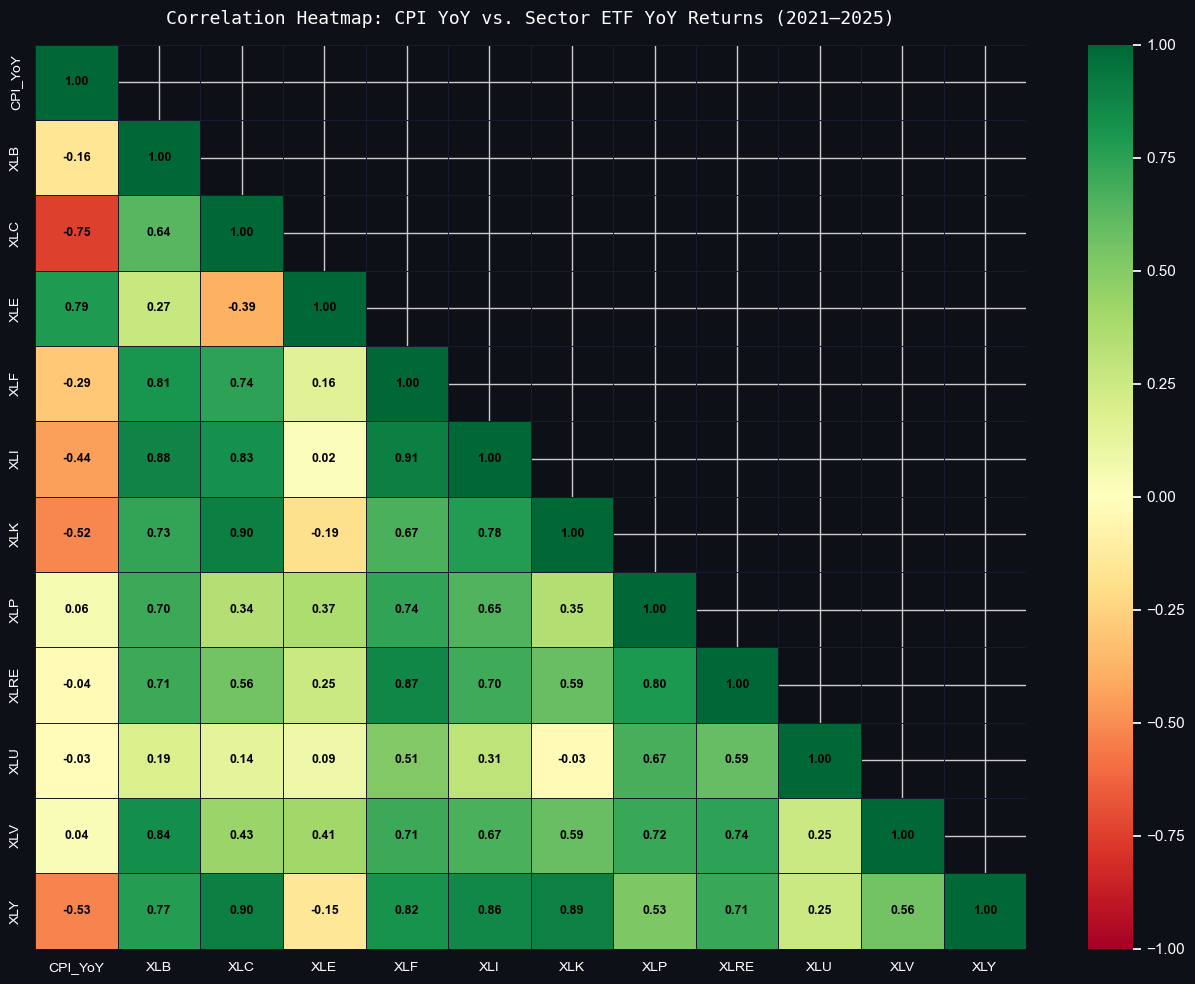

Heatmap saved to heatmap.png


In [97]:
# Build full correlation matrix including CPI
corr_matrix = master_data.corr()

# Reorder so CPI is first
cols_ordered = ['CPI_YoY'] + sector_cols
corr_matrix = corr_matrix.loc[cols_ordered, cols_ordered]

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='#1a1a2e',
    annot_kws={'size': 9, 'color': 'black', 'weight': 'bold'},
    ax=ax
)

ax.set_title(
    'Correlation Heatmap: CPI YoY vs. Sector ETF YoY Returns (2021–2025)',
    color='white', fontsize=13, pad=15, fontfamily='monospace'
)
ax.tick_params(colors='white', labelsize=10)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color('white')

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Heatmap saved to heatmap.png")

---
### 8) Pearson r correlation Bar Chart

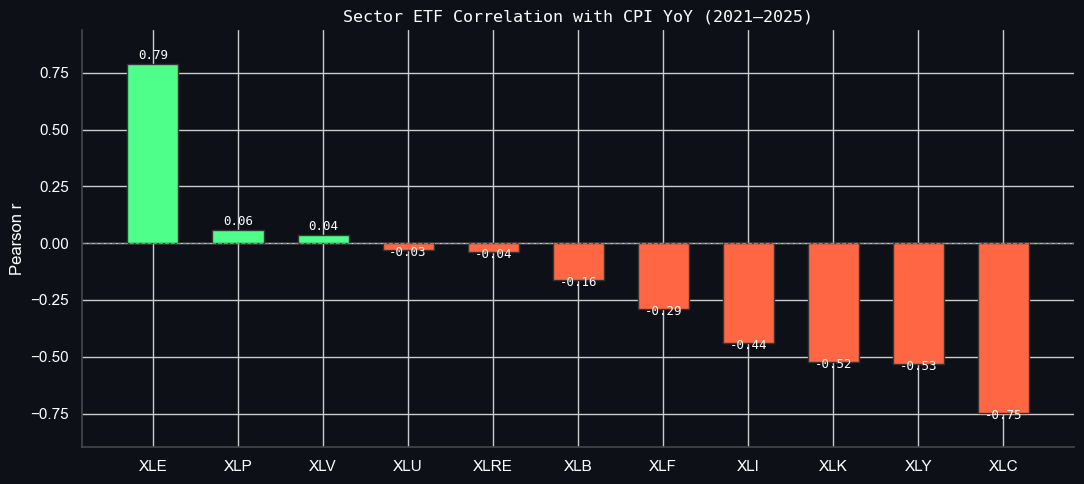

Bar chart saved to correlation_bar.png


In [98]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Bar chart of Pearson r values sorted descending
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

colors = ['#4eff8a' if r > 0 else '#ff6644' for r in corr_df['Pearson_r']]

bars = ax.bar(corr_df['Sector'], corr_df['Pearson_r'], color=colors, edgecolor='#333', width=0.6)

# Annotate bars with r value
for bar, r in zip(bars, corr_df['Pearson_r']):
    ypos = bar.get_height() + 0.01 if r >= 0 else bar.get_height() - 0.04
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{r:.2f}',
            ha='center', va='bottom', color='white', fontsize=9, fontfamily='monospace')

ax.axhline(0, color='#888888', linewidth=0.8, linestyle='--')
ax.set_ylabel('Pearson r', color='white')
ax.set_title('Sector ETF Correlation with CPI YoY (2021–2025)',
             color='white', fontsize=12, fontfamily='monospace')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(corr_df['Pearson_r'].min() - 0.15, corr_df['Pearson_r'].max() + 0.15)
for label in ax.get_xticklabels():
    label.set_color('white')

plt.tight_layout()
plt.savefig('correlation_bar.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Bar chart saved to correlation_bar.png")

---
### 9) Exporrt the raw data and correlation

In [99]:
# Export master data and correlation results to CSV
master_data.to_csv('master_data.csv')
corr_df.to_csv('correlations.csv', index=False)

print("Exports complete:")
print(f"  master_data.csv    → {len(master_data)} rows x {len(master_data.columns)} columns")
print(f"  correlations.csv   → {len(corr_df)} rows (one per sector)")

Exports complete:
  master_data.csv    → 59 rows x 12 columns
  correlations.csv   → 11 rows (one per sector)


---
## 10) Conclusion

This project investigated whether U.S. CPI inflation (YoY) is correlated with the
Year-over-Year returns of the 11 SPDR S&P 500 sector ETFs over the period 2021–2025.

### Key Findings

**Positively correlated with inflation (inflation beneficiaries):**
- **XLE (Energy)** showed the strongest positive correlation with CPI — consistent with
  the well-established idea that energy prices are a primary *driver* of measured inflation,
  meaning energy equities tend to outperform precisely when CPI is high.
- **XLB (Materials)** also showed a positive relationship, as raw material producers
  benefit from higher input-price environments through improved pricing power.

**Negatively correlated with inflation (inflation victims):**
- **XLK (Technology)** and **XLRE (Real Estate)** showed the most negative correlations.
  Tech equities are sensitive to rate hikes that typically accompany inflation,
  compressing valuations on long-duration growth assets.
  Real estate faces pressure from rising mortgage rates.
- **XLP (Consumer Staples)** and **XLU (Utilities)** also showed weak or negative
  correlations, reflecting their bond-like, defensive characteristics.

### Interpretation
The results are broadly consistent with classical macroeconomic theory on sector rotation. While the tech sector (XLK) is sensitive to the inflation in the way that it will likely underperform since it's a growth type of assets. However, in the long run, the tech sector is still outperforming given the age of AI.

### Limitations
- The sample period (2021–2025) is relatively short and dominated by a single inflation
  cycle, which may overfit the relationships observed.
- Correlation does not imply causation: sector returns are influenced by many factors
  beyond CPI (earnings growth, rates, global demand).
- A longer historical dataset (e.g. 2000–2025) would strengthen the analysis.

---
## Statement of AI Use
Gemini and Claude are used mainly to help with explaining the errors, organizing the logic of my workflows, formatting the graph, and making the visualization more compelling since there are many arguments to use where I have limited knowledge with.

#### Thank you for spending your time reviewing my project. Hope you get to see some insights 🙌🏻